In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [3]:
import matplotlib.style as style 
style.use('ggplot')

### Load Dataset 

In [4]:
df=pd.read_csv("C:\\Users\\JOHN\\Desktop\\ML_projects\\crop-recommendation-system\\data\\raw\\crop_data.csv")

In [5]:
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Dataset Overview

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


The dataset contains numerical soil and climate parameters with varying ranges, indicating the need for feature scaling during model training.

### Crop Distribution (Target Balance)

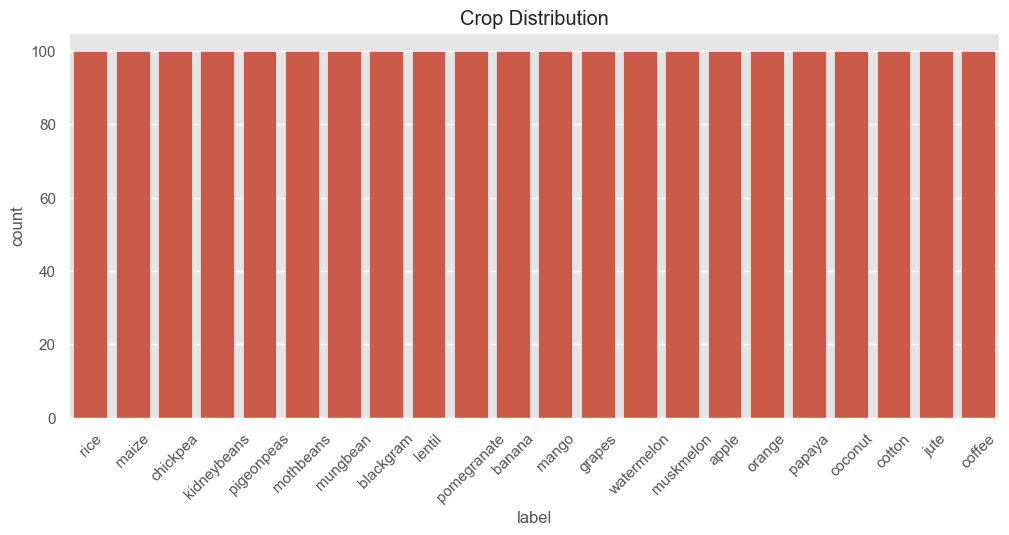

In [7]:
plt.figure(figsize=(12,5))
sns.countplot(x='label',data=df)
plt.xticks(rotation=45)
plt.title("Crop Distribution")
plt.show()

Crop classes are relatively balanced, making accuracy an appropriate evaluation metric.

### Correlation Heatmap

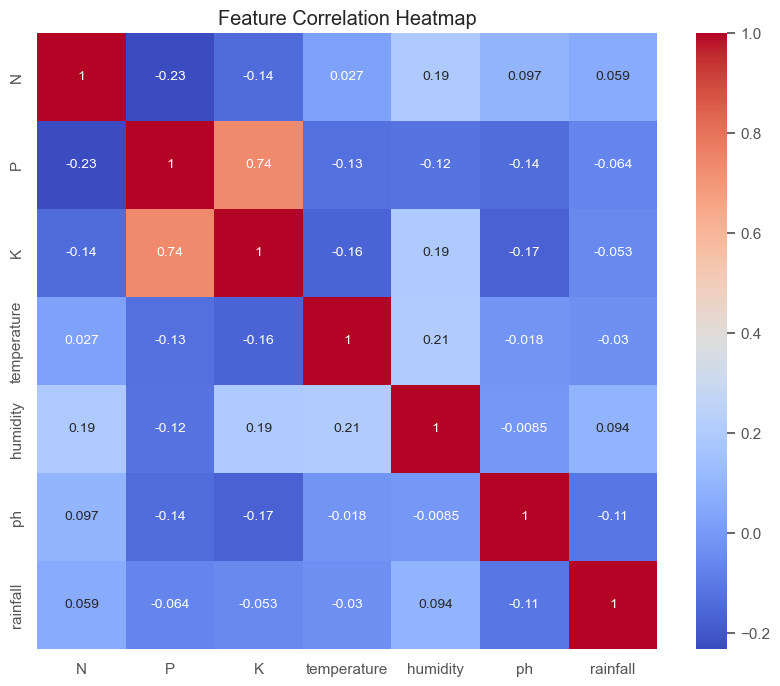

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

- Nutrient features (N, P, K) show moderate correlation

- Climate variables influence crop suitability independently


### Soil pH vs Crop

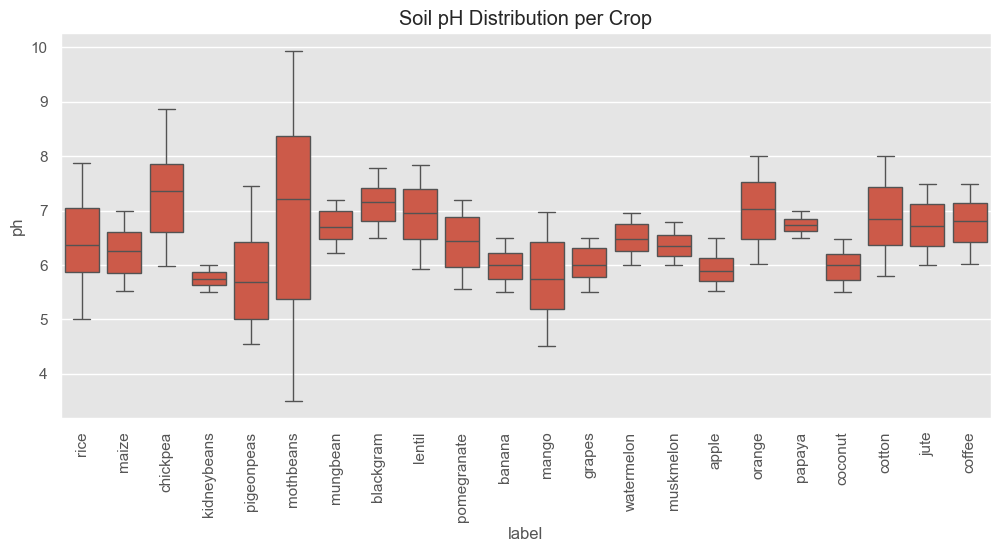

In [9]:
plt.figure(figsize=(12,5))
sns.boxplot(x='label', y='ph', data=df)
plt.xticks(rotation=90)
plt.title("Soil pH Distribution per Crop")
plt.show()

Different crops require distinct soil pH ranges, validating pH as a critical feature.

### Rainfall Analysis

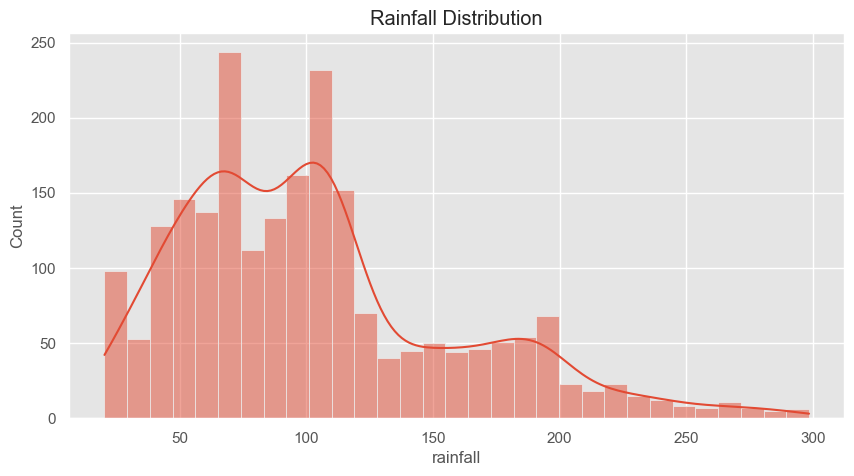

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['rainfall'], kde=True)
plt.title("Rainfall Distribution")
plt.show()

Rainfall shows a wide distribution, suggesting its strong influence on crop selection.

### Pairwise Feature Relationships

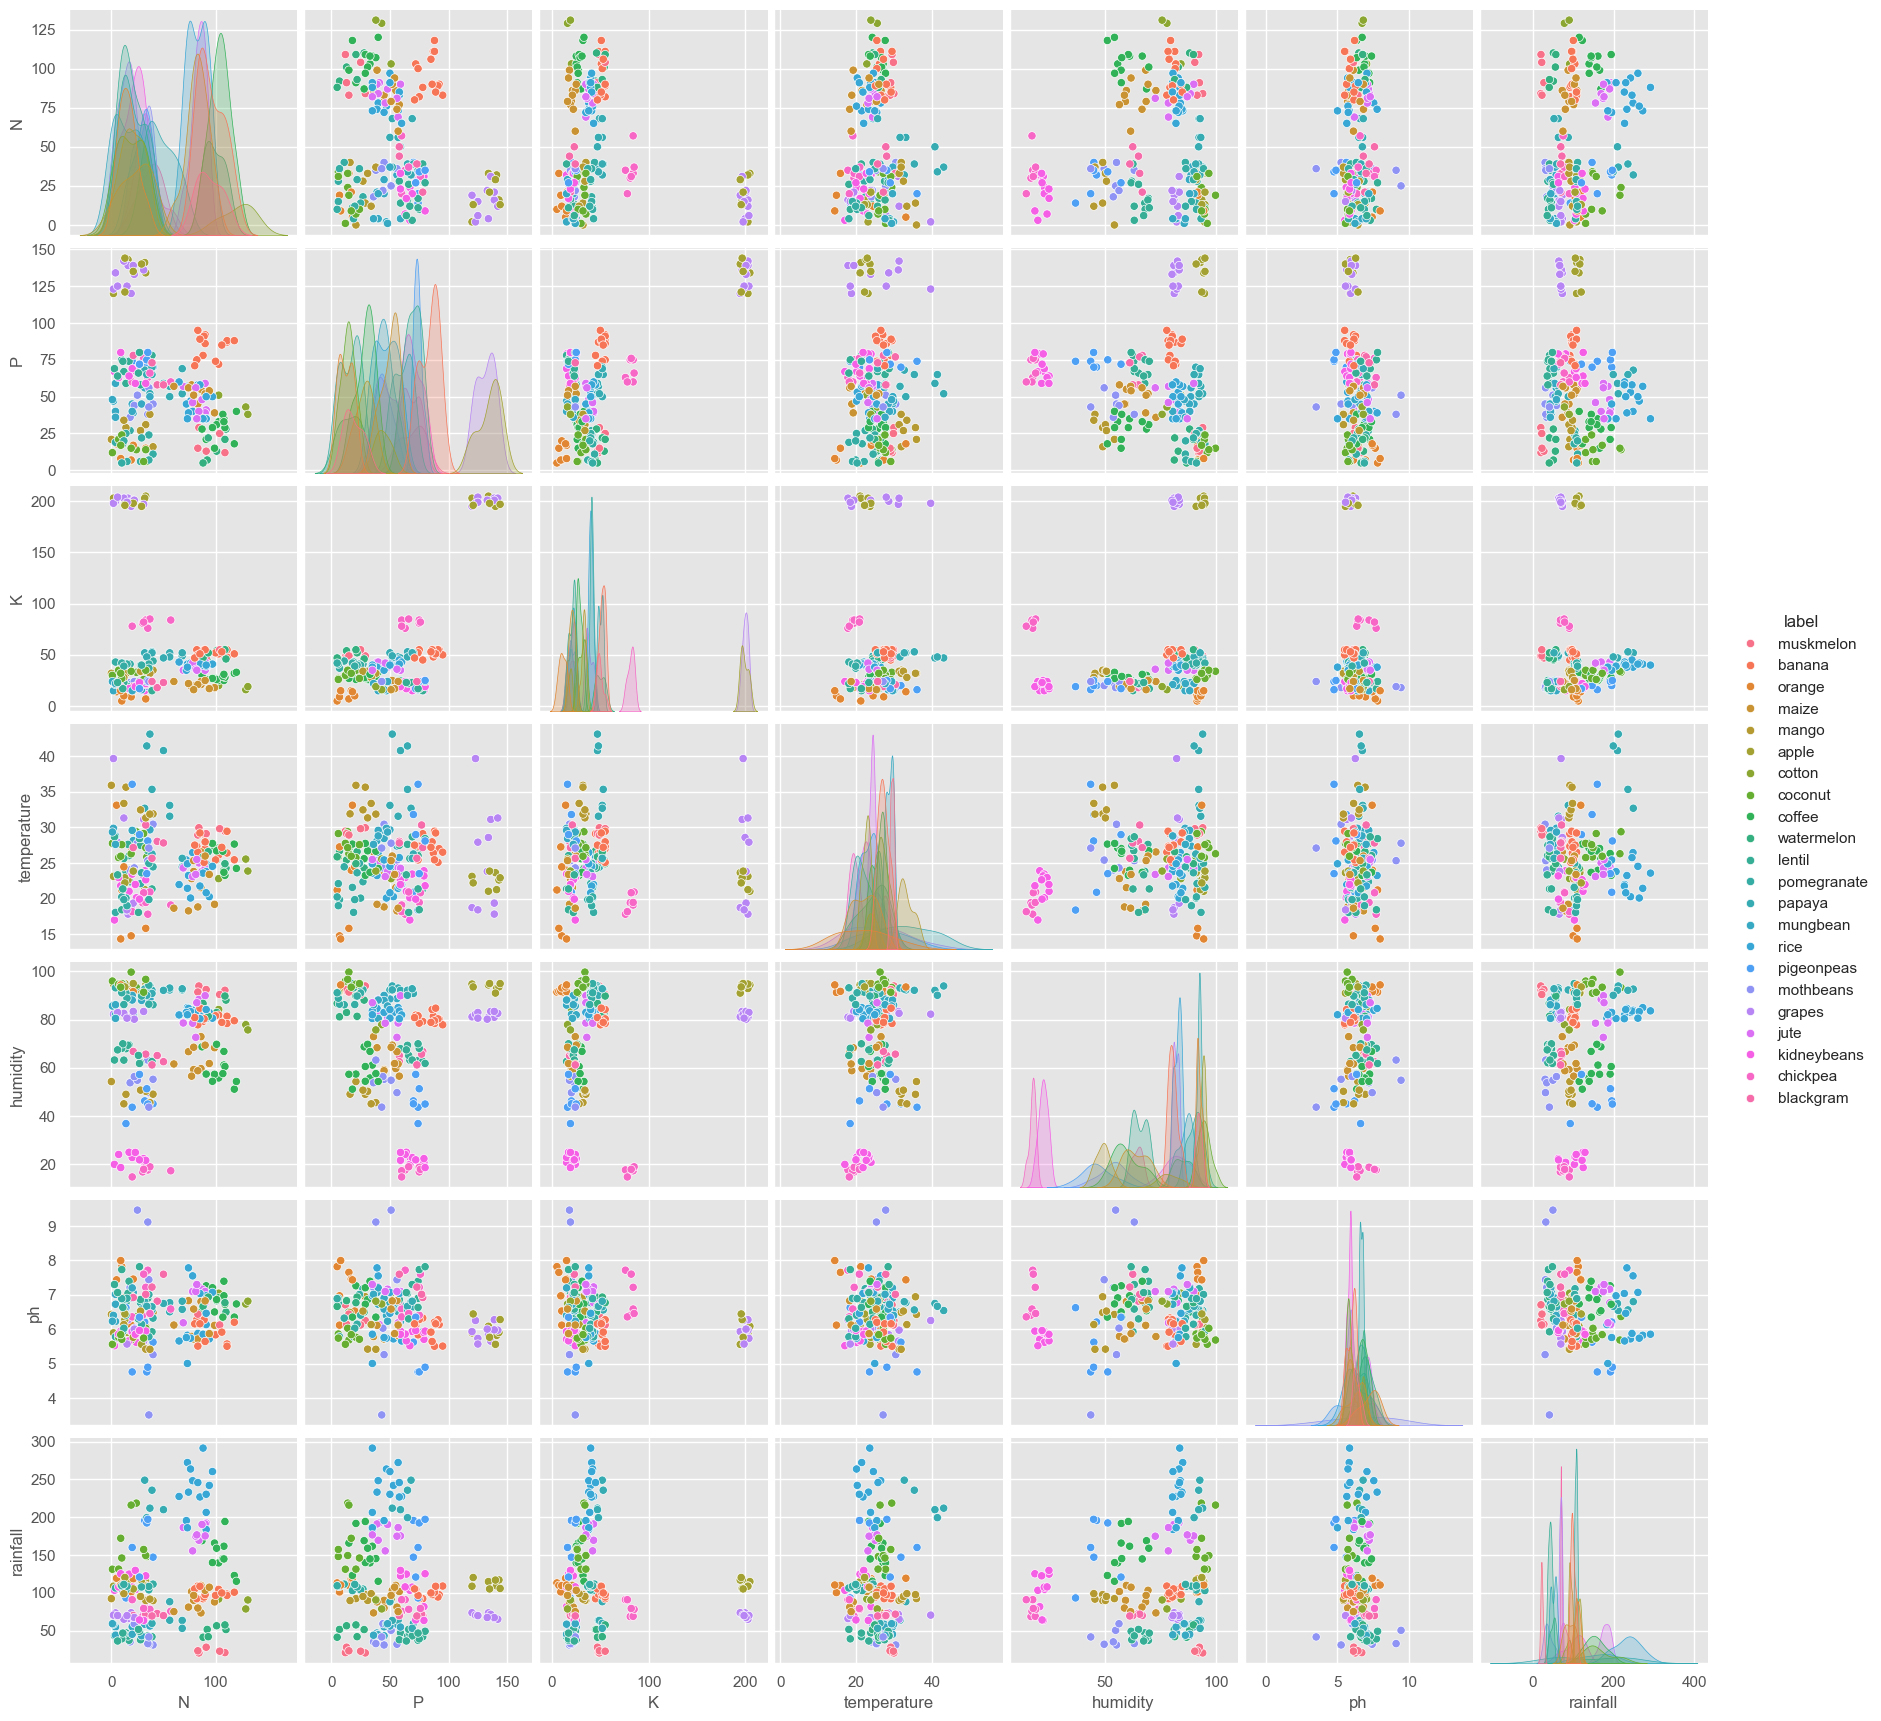

In [13]:
sns.pairplot(df.sample(200), hue='label')
plt.show()

### EDA Summary
The dataset exhibits clear separability among crops based on soil and climate features.

pH and rainfall are strong discriminative variables.

Feature scaling and tree-based models are suitable choices.